Seguindo nosso roadmap de machine learning\
Contexto do Problema:

Imobiliária tem dificuldades para precificar novos imóveis cadastrados;
 - Muitos clientes espalhados em diversas localidades
 - Incapaz de enviar corretores para avaliações em todos os imóveis (alto custo, viagem, diária, falta de conhecimento profundo de todas as regiões)
 - Precisa semanalmente precificar imóveis para atualizar o catálogo
 - Direcionar clientes para oportunidades certas com base no perfil dos clientes cadastrados

Tipificação do problema:
Precisamos prever um número, no caso, preço dos imóveis

Definição da Variável Dependente (Target ou Alvo)
- preco_venda

Coleta -- Essa etapa estamos pressundo que a ingestão foi feita diretamente pelo Sharepoint da Imobiliária com as 2 bases em CSV

Análise Exploratória:
- Já realizada no primeiro notebook de base_estatistica
- Faremos novamente de forma mais objetiva

Diferenciando ML e Programação Tradicional
- Programa Tradicional: Regras + Dados = Resultado

- Machine Learning:
Dados + Resultados --> Algoritimo --> Modelo --Novos Dados --> Previsão

Caso de uso:
A imobiliária tem dados históricos de clientes e imóveis cadastrados
Objetivo 1: Precificar imóveis novos
Objetivo 2: Classificar Clientes

Base Imóveis:
Características X Preço --> Algoritimo --> Modelo --> Novo Imóvel --> Preço previsto



Revisando os tipos de Modelo de Aprendizado no caso concreto:

**Supervisionado**
- Temos dados rotulados (histórico de preço conhecido)
- A máquina aprende com base nos rótulos que damos ao dado; [apartamento,casa] Já existe a resposta esperada
- 2 Formas de resolver problemas: 
    - Regressão: Prever valores numéricos (preços dos imóveis)
    - Classificação: Categoria (casa, apartamento;cliente vip, cliente comum)

Algoritimos:
- Regressão linear e Regressão logística (previsão de valor; previsão categórica) - preço do imóvel;cliente compra, não compra
- Regressão não linear Modelagem de exponenciais - previsão de desgaste de materiais
- Regressão polinomial - Prever eficiência (Produção agrícola) Pouco fertilizante menos planta. Qte ideal maxima produçao, Excesso mata a planta
- SVM Máquinas de Vetores de suporte - Encontra o limite que separa 2 classes (tumor maligno, benigno)
- Naive Bayes probabilidades com dados indpendentes - (chance de palavra grátis ser SPAM ou email normal)
- KNN Vizinho mais próximo  - Classifica um determinado ponto com base na maioria dos vizinhos
- Árvores de decisão - Fluxo binário Se A -> B - Aprovar emprestimo automático( renda maior que 3k)? Restrição CPF? , então Aprova ou Não aprova sob as condições V ou F

**Retornando a Base Imóveis**
- Já exploramos a base. Mas vamos retomar aqui
- Temoso preço
O que o algoritimo faz?
- Procura Padrões
    - Maiores imóveis custam mais (tendem)
    - Mais quartos estão vinculados ao maior valor
    - A idade influencia


In [2]:
# Importanto bibliotecas
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

In [3]:
# leitura do arquivo csv
df = pd.read_csv(r'C:\Users\yves59739656\Documents\projeto\ml_stat\bases_dados\base_imoveis.csv')

In [4]:
#df.head() #lista as colunas e 5 linhas iniciais (visualiza a base)

In [5]:
df.shape # olhando as dimensões da base

(5500, 9)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_imovel      5500 non-null   str    
 1   localidade     5210 non-null   str    
 2   tipo           5200 non-null   str    
 3   area_m2        5216 non-null   float64
 4   quartos        5156 non-null   float64
 5   banheiros      5182 non-null   float64
 6   vagas_garagem  5181 non-null   float64
 7   idade_anos     5180 non-null   float64
 8   preco_venda    5173 non-null   float64
dtypes: float64(6), str(3)
memory usage: 530.1 KB


In [7]:
# Resumo estatisitco 
df.describe()

,area_m2,quartos,banheiros,vagas_garagem,idade_anos,preco_venda
count,5216.000000,5156.000000,5182.000000,5181.000000,5180.000000,5.173000e+03
mean,294.827837,3.621412,4.149170,2.566879,20.087645,8.732209e+05
std,163.986606,1.113622,1.792976,1.071757,11.778055,7.552051e+05
min,40.000000,1.000000,1.000000,0.000000,0.000000,7.895600e+04
25%,148.000000,3.000000,3.000000,2.000000,10.000000,4.036640e+05
50%,275.000000,4.000000,4.000000,3.000000,20.000000,6.653100e+05
75%,439.000000,5.000000,5.000000,3.000000,30.000000,1.076094e+06
max,600.000000,5.000000,7.000000,4.000000,40.000000,7.373758e+06


Qualidade dos dados

In [8]:
nulos = pd.DataFrame({
    "Nulos": df.isnull().sum(),
    "% Nulos": df.isnull().mean() * 100
})

nulos.sort_values("% Nulos", ascending=False)

,Nulos,% Nulos
quartos,344,6.254545
preco_venda,327,5.945455
idade_anos,320,5.818182
vagas_garagem,319,5.800000
banheiros,318,5.781818
tipo,300,5.454545
localidade,290,5.272727
area_m2,284,5.163636
id_imovel,0,0.000000


Pergunta 1: Qual variável possui mais nulos?

Pergunta 2: Qual possui menos?

Pergunta 3: Qual variável é o nosso alvo?

Pergunta 4: Podemos simplesmente preencher preco_venda com a mediana?

Pergunta 5: O tratamento de area_m2 deve ser necessariamente igual ao tratamento de localidade?

A analise dos nulos depende do que queremos analisar
se o nosso alvo é o preço, e temos valores nulos, o modelo não aprende pois não há o gabarito (a supervisão)

Logo esse valor deve ser eliminado do conjunto
Para outros valores nulos, podemos simplesmente usar a mediana para preencher os nulos 
ou ainda usar a moda(valor que mais se repete nas categoricas)

| Percentual de nulos | Interpretação didática                   |
| ------------------: | ---------------------------------------- |
|                0–2% | Baixo impacto                            |
|                2–5% | Atenção                                  |
|               5–10% | Necessita tratamento                     |
|                >10% | Investigar cuidadosamente                |
|                >30% | Variável pode precisar ser reconsiderada |


In [9]:
df_modelo = df.dropna(subset=["preco_venda"]).copy() # removemos os nulos para o treinamento
df["area_m2"].fillna(df["area_m2"].median()) # para area por exemplo podemos preencher os nulos pela mediana

0       152.0
1       126.0
2       587.0
3        78.0
4       255.0
        ...  
5495    244.0
5496    138.0
5497    344.0
5498    215.0
5499    519.0
Name: area_m2, Length: 5500, dtype: float64

In [10]:
# Separando as vaiaveis dependentes das independentes
# No caso nosso alvo é a variável independente ou target (preco_venda)
features = [
    "localidade",
    "tipo",
    "area_m2",
    "quartos",
    "banheiros",
    "vagas_garagem",
    "idade_anos"
]

target = "preco_venda"

X = df[features]
y = df[target]

In [11]:
#Treinamento do Modelo Definição dos parametos
#IMPORTANTE INSTALAR O SCIKIT LEARN antes !pip install scikit-learn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

!treinamos o modelo com 80% dos dados
os 20 % restantes é a parte do conjunto testada

**Variáveis Categóricas**
OneHotEncoder é a solução para transformar nossos dados categóricos
Então por isso separamos as features numericas das não numéricas...No nosso EDA vimos que localidade e tipo são "Object" 


**Pipeline de preparação**
Pipeline é uma sequência organizada e automática de etapas que transforma os dados "como eles chegam" em dados prontos para o modelo.

Seria essa sequencia:
Dados originais → limpeza → preenchimento → transformação → modelo → previsão

o algoritmo precisa receber os dados em uma *representação numérica.*

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline # O pipeline garante que as mesmas transformações utilizadas no treinamento sejam aplicadas aos novos imóveis posteriormente.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    "area_m2",
    "quartos",
    "banheiros",
    "vagas_garagem",
    "idade_anos"
]

categorical_features = [
    "localidade",
    "tipo"
]

In [13]:
#Tratamento numerico
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")) # vamos usar a mediana para tratar os nulos numéricos
    ]
)

#tratamento categorico
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")), #aqui usamos a moda para imputar o mais frequente p/ substituir nulos
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)


In [14]:
#Juntanto todo o processo
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [15]:
#Algoritimo de RL
from sklearn.linear_model import LinearRegression

modelo_linear = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [16]:
modelo_linear.fit(X_train, y_train)

ValueError: Input y contains NaN.

**NULOS de preco_venda não tratados**
nulos das variaveis x(variaveis independentes foram tratados pela mediana e pela moda)
nulos da variavel y (preco_venda) também precisam ser tratados...
MAS, não podemos inserir mediana para ele, pois estariamos *INVENTANDO* um gabarito, compromentendo a eficiencia do modelo
logo, y_train não pode conter NAN(nulos)

antes de x e y desta celula precisa acontecer <df_modelo = df.dropna(subset=["preco_venda"]).copy()> # removemos os nulos para o treinamento

Então executamos esse processo novamente, caso tenha havido falha
Depois, contamos os null, o rsltado deve ser zero 

In [22]:
df_modelo = df.dropna(subset=["preco_venda"]).copy() #Dropando nulos da variavel y

In [23]:
df_modelo["preco_venda"].isnull().sum()#confirmando o resultado de drop null

np.int64(0)

In [25]:
#Recriando features e target e a divisão Treinamento e teste
features = [
    "localidade",
    "tipo",
    "area_m2",
    "quartos",
    "banheiros",
    "vagas_garagem",
    "idade_anos"
]

target = "preco_venda"

X = df_modelo[features]
y = df_modelo[target]


#Roda novamente treinamento
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [23]:
modelo_linear.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['localidade','tipo','area_m2',...,'banheiros','vagas_garagem', 'idade_anos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of col

INTERPRETANDO O MODELO
PIPELINE É A SEQUENCIA DE ETAPAS:
1 - PROCESSOR :
2 - LINEAR REGRESSION

Processor>>preprocesso: ColumnTransformer (Idenfica e indica ao python as colunas texto e colunas numericas) -> Cada grupo deve receber um tratamento diferente
    Num e cat---foram imputadas as features os valores
        cat 2 featrures(localidade e tipo) viraram 70 features. Por que?
        ONE-Hot-Enconding fez isso...houve uma transformação de 0 e 1 para cada localidade e cada tipo...criando rotulos para esas colunas **Não foram adicionadas novas informações**
Ao final temos 75 colunas rotuladas, ou seja com seus respectivos gabaritos (Confirmando a Modelagem Supervisionada)

Conclusão: O modelo não está recebendo as 7 colunas originais. Ele está recebendo 75 colunas transformadas.

**LinearRegression**
Preço = β0 + β1Área + β2Quartos + β3Banheiros + ...
Preço =  β0 + β1 × área +β2 × quartos + ...+ β75 × alguma representação 
Ou seja o preço foi traçado pela combinação de todas as retas possiveis para cada feature para aprender a achar a melhor reta possível para precificar


Então até aqui aprendemos como o modelo foi construido
e o fit(X_train, y_train)  é quando o modelo aprende com os exemplos disponíveis.

Realizando o teste de predição e auferindo resultados

In [24]:
#Agora com o que foi aprendido, faça as previsões...isso que está sendo feito nessa fase.
y_pred_linear = modelo_linear.predict(X_test)

A predição está pronta!
Agora vamos analisar as previsões, preços reais e os erros da previsão

Por exemplo:


| Imóvel | Preço real | Preço previsto |
| :--- | :--- | :--- |
| A | R$ 700.000 | R$ 680.000 |
| B | R$ 900.000 | R$ 950.000 |
| C | R$ 500.000 | R$ 520.000 |

Para cada imovél foi previsto um preço e tinhamos o preço real
Então, precisamos saber o quanto o modelo erra em média (MAE) - Erro médio absoluto

In [25]:
from sklearn.metrics import mean_absolute_error 
mae_linear = mean_absolute_error( y_test, y_pred_linear )
print(f"MAE: R$ {mae_linear:,.2f}") 
'''botei a string R$ p/ facilitar a visulizacao do que estamos interpretando indicar que é em reais, 
e o :,.2f para formatar o número com vírgula como separador de milhar e 2 casas decimais.'''

MAE: R$ 202,419.53


'botei a string R$ p/ facilitar a visulizacao do que estamos interpretando indicar que é em reais, \ne o :,.2f para formatar o número com vírgula como separador de milhar e 2 casas decimais.'

**Erro Quadrado** ou **RMSE -Root Mean Squared Error**\
Se o erro de um modelo **A** é
| Erro | Valor |
| :--- | :--- |
| Erro 1 | R$ 10.000 |
| Erro 2 | R$ 20.000 |
| Erro 3 | R$ 30.000 |

e do Modelo **B** é:

| Erro | Valor |
| :--- | :--- |
| Erro 1 | R$ 5.000 |
| Erro 2 | R$ 10.000 |
| Erro 3 | R$ 100.000 |




QUAL modelo possui maior erro entre A  e B ?


A Raiz quadrada do erro médio(RMSE) é o crescimento exponencial do erro.\
Esse indicador penaliza grandes erros (outliers)\
Assim, se o erro médio for 4, então RMSE = 4² ou seja 16.\
Essa métrica mostra se o modelo está cometendo ou não erros absurdos.

Em última instância, significa que os erros ganham maior peso, ou ainda\
há uma "punição" mais severa quando o modelo comete erros.

Maior peso - Consequencia matemática,pois o erro está elevado ao quadrado\
Punição - É meramente um peso desproporcional ao erro.

*OBS: Não confundir com chamada puniçao dos modelos por reforço(onde a resposta negativa sinaliza que a decisão foi errada/ruim)\
modificando a probabilidade*


**Cálculo da RMSE**

In [ ]:
from sklearn.metrics import mean_squared_error 
rmse_linear = np.sqrt( mean_squared_error( y_test, y_pred_linear ) ) 
print(f"RMSE: R$ {rmse_linear:,.2f}")

MAE VS RMSE
Erro Médio Absoluto e Raiz Quadrada do Erro:
**Interpretação:**

MAE =~ 202.419\
RMSE =~ 329.888\
Há uma diferença muito grande entre os erros, isso significa que temos que investigar...
No caso dos imóveis, pensando no PI a margem de 20% estaria totalmente violada, uma vez que o RMSE
seria nosso indicador de tolerancia dessa margem.

**R² — Coeficiente de determinação**

**Quanto da variação dos preços o modelo consegue explicar?**\
ou ainda\
** Métrica da qualidade global do modelo de RL**

Resposta simples: O modelo é útil ou um chute é melhor
Quanto mais próximo de 1, mais explicada é a variação nesse dataset.

Em síntese, podemos interpretar assim: Se não tivesse um modelo de ML e alguem pergunta:\
-Qual é a média dos preços de imóvel da sua carteira, dando um chute, só olhando ali o que voce sabe no dia a dia?

O R² compara esse chute baseado na média, pra saber quanto o modelo melhora essa previsão.

Ele não está na mesma unidade de MAE E RMSE, mas entre 0 e 1 ou seja um percentual.


*OBS*   **R² não é a precisão!!!**
Mas o quanto esse modelo explica a variação de preços, por exemplo

Quanto mais perto de 1, **comumente** melhor (cada modelo de negócio define essas margens do que é aceitavel)

In [ ]:
from sklearn.metrics import ( mean_absolute_error, mean_squared_error, r2_score )
mae_linear = mean_absolute_error( y_test, y_pred_linear )
rmse_linear = np.sqrt( mean_squared_error( y_test, y_pred_linear ) )
r2_linear = r2_score( y_test, y_pred_linear )


In [29]:
from sklearn.metrics import r2_score
r2_linear = r2_score( y_test, y_pred_linear )
print(f"R²: {r2_linear:.4f}")

print(f"MAE : R$ {mae_linear:,.2f}") 
print(f"RMSE: R$ {rmse_linear:,.2f}") 
print(f"R² : {r2_linear:.4f}")

R²: 0.8288
MAE : R$ 202,419.53
RMSE: R$ 329,888.56
R² : 0.8288


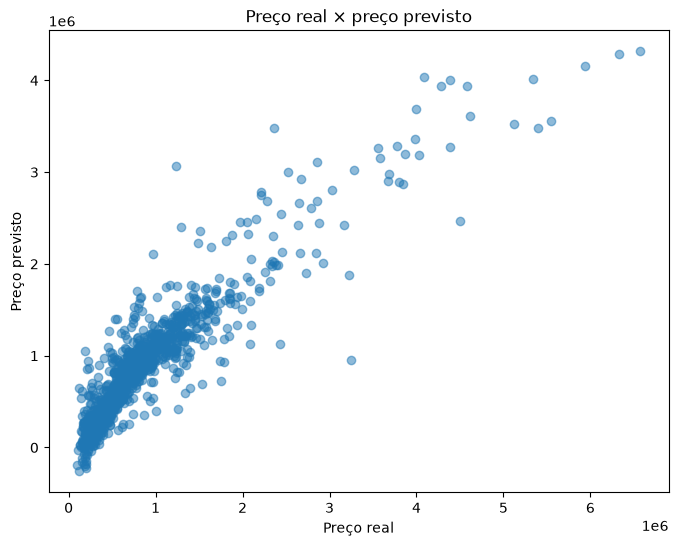

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter( y_test, y_pred_linear, alpha=0.5 )
plt.xlabel("Preço real") 
plt.ylabel("Preço previsto") 
plt.title("Preço real × preço previsto") 
plt.show()

QUAIS CONCLUSÕES podemos ter diante da ANALISE dos 3 indicadores e do gráfic?
- O Modelo é bom?

Ainda há oportunidades de ajuste?
A Regressão Linear é o melhor opção?
Aplicar função logariti

PROXIMOS PASSOS: aplicar transformação Logarítmica (log(y)) 

In [ ]:
#ARVORES DE DECISÃO E COmparação entre modelos
from sklearn.tree import DecisionTreeRegressor

In [ ]:
P